In [1]:
# ─── Install / upgrade packages ───────────────────────────────────────────────
!pip install -q "transformers>=4.41.0" timm evaluate rouge_score bert_score accelerate sentencepiece
!pip install -q Pillow tqdm pandas numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.6 MB/s eta 0:00:00


In [6]:
import os, json, re, gc, random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from transformers import (
    ViTModel, AutoImageProcessor,
    GPT2LMHeadModel, GPT2Tokenizer,
    get_cosine_schedule_with_warmup,
    AutoTokenizer, AutoModel
)
import evaluate

# ─── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ─── Device setup ─────────────────────────────────────────────────────────────
NUM_GPUS = torch.cuda.device_count()
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP  = (NUM_GPUS > 0)  # Mixed precision on GPU
print(f'GPUs found: {NUM_GPUS} | Device: {DEVICE} | AMP: {USE_AMP}')
for i in range(NUM_GPUS):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

GPUs found: 2 | Device: cuda | AMP: True
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — edit paths to match your Kaggle dataset
# ─────────────────────────────────────────────────────────────────────────────

class CFG:
    # ── Paths ────────────────────────────────────────────────────────────────
    DATA_ROOT     = Path('/kaggle/input/datasets/madhabpadhi/medical1-0/dev_caption_synth')
    IMAGES_DIR    = DATA_ROOT / 'images'
    CAPTIONS_FILE = DATA_ROOT / 'captions.csv'          
    ATTRIBUTION_FILE = DATA_ROOT / 'attribution.csv'
    OUTPUT_DIR    = Path('/kaggle/working/outputs')
    MODEL_DIR     = Path('/kaggle/working/checkpoints')

    # ── Model ────────────────────────────────────────────────────────────────
    # Vision encoder options (pick one):
    VIT_MODEL     = 'google/vit-base-patch16-224'

    # Text decoder options:
    GPT_MODEL     = 'gpt2'

    # ── Image ────────────────────────────────────────────────────────────────
    IMG_SIZE      = 224
    IMG_MEAN      = (0.485, 0.456, 0.406)   # ImageNet mean
    IMG_STD       = (0.229, 0.224, 0.225)   # ImageNet std

    # ── Text ─────────────────────────────────────────────────────────────────
    MAX_LEN       = 128   # max caption token length

    # ── Training ─────────────────────────────────────────────────────────────
    # Phase 1: freeze encoder, train decoder only
    PHASE1_EPOCHS = 3
    PHASE1_LR     = 5e-4

    # Phase 2: unfreeze all, end-to-end fine-tuning
    PHASE2_EPOCHS = 5
    PHASE2_LR     = 1e-5

    # T4 x2: batch 8 per GPU → effective 16
    # P100:  batch 16 (larger VRAM per card)
    BATCH_SIZE    = 8 if NUM_GPUS <= 1 else 8  # per GPU
    GRAD_ACCUM    = 2   # effective batch = BATCH_SIZE * NUM_GPUS * GRAD_ACCUM
    WARMUP_STEPS  = 200
    WEIGHT_DECAY  = 0.01
    MAX_GRAD_NORM = 1.0

    # ── Inference ────────────────────────────────────────────────────────────
    BEAM_SIZE     = 4
    MAX_NEW_TOKENS = 100

    # ── Split ────────────────────────────────────────────────────────────────
    VAL_FRAC      = 0.05   # 5% validation split

CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CFG.MODEL_DIR.mkdir(parents=True, exist_ok=True)
print('Config OK')

Config OK


In [8]:
# ─── Load captions file ───────────────────────────────────────────────────────
# The captions file is typically a TSV with columns: image_id, caption
# Adjust sep and column names based on your actual file format

def load_captions(path: Path) -> pd.DataFrame:
    """Load the captions file. Handles CSV and TSV."""
    suffix = path.suffix.lower()
    sep = '\t' if suffix == '.tsv' else ','
    df = pd.read_csv(path, sep=sep)

    # Normalise column names to lowercase
    df.columns = [c.strip().lower() for c in df.columns]
    print(f'Columns found: {list(df.columns)}')

    # Try to identify image_id and caption columns
    id_col  = next((c for c in df.columns if 'id'      in c or 'image' in c or 'file' in c), df.columns[0])
    cap_col = next((c for c in df.columns if 'caption' in c or 'text'  in c or 'label' in c), df.columns[1])
    df = df[[id_col, cap_col]].rename(columns={id_col: 'image_id', cap_col: 'caption'})

    # Clean
    df = df.dropna()
    df['caption'] = df['caption'].astype(str).str.strip()
    df['image_id'] = df['image_id'].astype(str).str.strip()
    return df

df = load_captions(CFG.CAPTIONS_FILE)
print(f'Total samples: {len(df):,}')
df.head()

Columns found: ['id', 'caption']
Total samples: 116,461


,image_id,caption
0,ImageCLEFmedical_Caption_2026_synth_train_000000,MRI of the spine in sagittal plane showing the...
1,ImageCLEFmedical_Caption_2026_synth_train_000001,Angiography/fluoroscopy of the chest showing a...
2,ImageCLEFmedical_Caption_2026_synth_train_000002,"CT of the abdomen, axial view, showing a hyper..."
3,ImageCLEFmedical_Caption_2026_synth_train_000003,X-ray radiograph of the abdomen showing dilate...
4,ImageCLEFmedical_Caption_2026_synth_train_000004,Fluoroscopy image of the abdomen showing ballo...


count    116461.000000
mean         30.421532
std           8.390213
min           8.000000
25%          25.000000
50%          29.000000
75%          35.000000
max         106.000000
Name: cap_len, dtype: float64


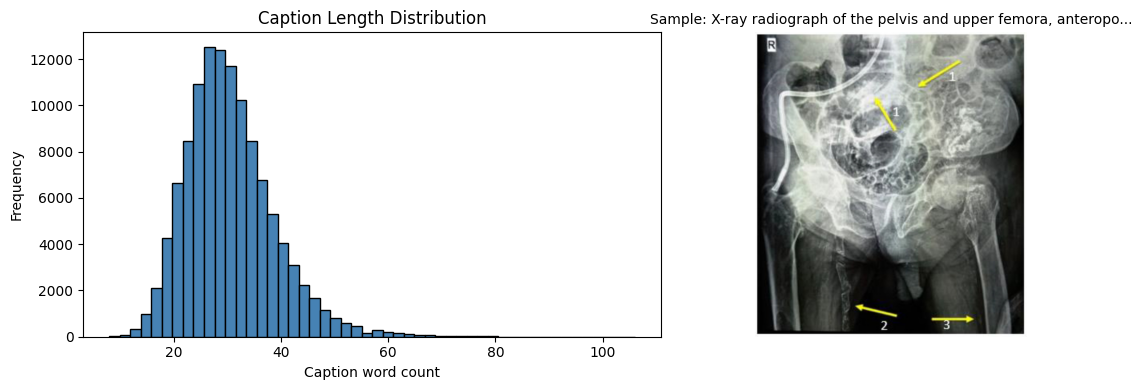

In [9]:
import matplotlib.pyplot as plt

# Caption length distribution
df['cap_len'] = df['caption'].str.split().str.len()
print(df['cap_len'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Histogram
axes[0].hist(df['cap_len'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Caption word count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Caption Length Distribution')

# Right plot: Show a sample image
sample = df.sample(4, random_state=SEED)
image_found = False

for i, (_, row) in enumerate(sample.iterrows()):
    img_path = CFG.IMAGES_DIR / row['image_id']
    
    # Try with/without extension
    if not img_path.exists():
        for ext in ['.jpg', '.jpeg', '.png', '.tif']:
            candidate = CFG.IMAGES_DIR / (row['image_id'] + ext)
            if candidate.exists():
                img_path = candidate
                break

    # If we found an image, plot it and break
    if img_path.exists():
        img = Image.open(img_path).convert('RGB')
        axes[1].imshow(img)
        axes[1].axis('off')
        
        # Truncate caption so it doesn't spill off the figure
        caption = row['caption']
        short_cap = caption if len(caption) < 60 else caption[:57] + '...'
        axes[1].set_title(f"Sample: {short_cap}", wrap=True, fontsize=10)
        
        image_found = True
        break  

if not image_found:
    axes[1].text(0.5, 0.5, 'Images not found in path', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'eda.png', dpi=120)
plt.show()

In [10]:
# ─── Build image paths (handle missing extensions) ───────────────────────────
EXTENSIONS = ['.jpg', '.jpeg', '.png', '.tif', '.tiff', '.gif']

def resolve_image_path(image_id: str, images_dir: Path) -> Path | None:
    """Find image file regardless of whether extension is in image_id."""
    p = images_dir / image_id
    if p.exists():
        return p
    for ext in EXTENSIONS:
        p2 = images_dir / (image_id + ext)
        if p2.exists():
            return p2
    return None

# Build a resolved path column
tqdm.pandas(desc='Resolving image paths')
df['img_path'] = df['image_id'].progress_apply(
    lambda x: resolve_image_path(x, CFG.IMAGES_DIR)
)

missing = df['img_path'].isna().sum()
print(f'Missing images: {missing:,} / {len(df):,}')

# Drop rows without a resolved image
df = df.dropna(subset=['img_path']).reset_index(drop=True)
df['img_path'] = df['img_path'].astype(str)
print(f'Usable samples: {len(df):,}')

Resolving image paths:   0%|          | 0/116461 [00:00<?, ?it/s]

Missing images: 0 / 116,461
Usable samples: 116,461


In [11]:
from torchvision import transforms as T

# Training augmentations (light — medical images need care)
TRAIN_TRANSFORMS = T.Compose([
    T.Resize((CFG.IMG_SIZE + 32, CFG.IMG_SIZE + 32)),
    T.RandomCrop(CFG.IMG_SIZE),
    T.RandomHorizontalFlip(p=0.3),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=CFG.IMG_MEAN, std=CFG.IMG_STD),
])

VAL_TRANSFORMS = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=CFG.IMG_MEAN, std=CFG.IMG_STD),
])

In [12]:
class MedicalCaptionDataset(Dataset):
    """Medical image captioning dataset."""

    def __init__(self, df: pd.DataFrame, tokenizer, transform, is_train: bool = True):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.is_train  = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img_path = row['img_path']
        caption  = row['caption']

        # ── Load image ───────────────────────────────────────────────────────
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            # Fallback: blank image
            img = Image.new('RGB', (CFG.IMG_SIZE, CFG.IMG_SIZE), 0)

        pixel_values = self.transform(img)   # [3, H, W]

        # ── Tokenize caption ─────────────────────────────────────────────────
        # Add BOS token; labels shift left (teacher forcing)
        enc = self.tokenizer(
            caption,
            max_length=CFG.MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = enc['input_ids'].squeeze(0)       # [L]
        attention_mask = enc['attention_mask'].squeeze(0)  # [L]

        # Labels: -100 on padding tokens (ignored in loss)
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        return {
            'pixel_values':  pixel_values,
            'input_ids':     input_ids,
            'attention_mask': attention_mask,
            'labels':        labels,
            'image_id':      row['image_id']
        }

In [13]:
# ─── Tokenizer ────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(CFG.GPT_MODEL)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.bos_token_id = tokenizer.eos_token_id  # GPT-2 uses EOS as BOS

# ─── Train / val split ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df, test_size=CFG.VAL_FRAC, random_state=SEED
)
print(f'Train: {len(train_df):,} | Val: {len(val_df):,}')

# ─── Datasets & loaders ───────────────────────────────────────────────────────
train_ds = MedicalCaptionDataset(train_df, tokenizer, TRAIN_TRANSFORMS, is_train=True)
val_ds   = MedicalCaptionDataset(val_df,   tokenizer, VAL_TRANSFORMS,   is_train=False)

train_loader = DataLoader(
    train_ds,
    batch_size  = CFG.BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True
)
val_loader = DataLoader(
    val_ds,
    batch_size  = CFG.BATCH_SIZE * 2,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 110,637 | Val: 5,824
Train batches: 13830 | Val batches: 364


## 3. Model Architecture

We use a **Vision-Language** encoder-decoder:
- **Encoder**: ViT (or BioViL-T) — produces image patch embeddings
- **Bridge**: linear projection + cross-attention prefix tokens fed to GPT-2
- **Decoder**: GPT-2 (or BioGPT) — auto-regressively generates the caption

In [14]:
class MedicalCaptionModel(nn.Module):
    """
    Vision-Language model for medical image captioning.
    Architecture: ViT encoder → linear projection → GPT-2 decoder (prefix injection)
    """

    def __init__(self, vit_name: str, gpt_name: str, freeze_encoder: bool = True):
        super().__init__()

        # ── Vision encoder ───────────────────────────────────────────────────
        self.encoder = ViTModel.from_pretrained(vit_name)
        enc_dim = self.encoder.config.hidden_size    # e.g. 768 for ViT-base

        # ── Text decoder ─────────────────────────────────────────────────────
        self.decoder = GPT2LMHeadModel.from_pretrained(gpt_name)
        dec_dim = self.decoder.config.n_embd          # e.g. 768 for GPT-2

        # ── Projection: encoder dim → decoder dim ────────────────────────────
        self.proj = nn.Sequential(
            nn.Linear(enc_dim, dec_dim),
            nn.GELU(),
            nn.LayerNorm(dec_dim),
        )

        # ── Freeze encoder (Phase 1) ──────────────────────────────────────────
        self.freeze_encoder(freeze_encoder)

        # Make sure padding token is set
        self.decoder.config.pad_token_id = self.decoder.config.eos_token_id

    def freeze_encoder(self, freeze: bool):
        for p in self.encoder.parameters():
            p.requires_grad = not freeze
        status = 'FROZEN' if freeze else 'TRAINABLE'
        print(f'Encoder is now {status}')

    def encode_image(self, pixel_values):
        """Run ViT, return patch tokens projected to decoder dim."""
        out    = self.encoder(pixel_values=pixel_values)
        # out.last_hidden_state: [B, num_patches+1, enc_dim]
        visual = self.proj(out.last_hidden_state)   # [B, num_patches+1, dec_dim]
        return visual

    def forward(self, pixel_values, input_ids, attention_mask, labels=None):
        """
        Training forward pass.
        Visual tokens are prepended to the text token embeddings as a prefix.
        """
        B = pixel_values.size(0)

        # ── Image prefix tokens ──────────────────────────────────────────────
        visual_tokens = self.encode_image(pixel_values)   # [B, Nv, D]
        Nv = visual_tokens.size(1)

        # ── Text embeddings ──────────────────────────────────────────────────
        text_embeds = self.decoder.transformer.wte(input_ids)  # [B, L, D]

        # ── Concatenate: [visual | text] ─────────────────────────────────────
        inputs_embeds = torch.cat([visual_tokens, text_embeds], dim=1)  # [B, Nv+L, D]

        # Extend attention mask for visual prefix (all 1s)
        vis_mask = torch.ones(B, Nv, device=attention_mask.device, dtype=attention_mask.dtype)
        full_mask = torch.cat([vis_mask, attention_mask], dim=1)  # [B, Nv+L]

        # Labels: ignore visual prefix positions (-100), then text labels
        if labels is not None:
            vis_labels   = torch.full((B, Nv), -100, device=labels.device, dtype=labels.dtype)
            full_labels  = torch.cat([vis_labels, labels], dim=1)  # [B, Nv+L]
        else:
            full_labels = None

        outputs = self.decoder(
            inputs_embeds=inputs_embeds,
            attention_mask=full_mask,
            labels=full_labels,
        )
        return outputs

    @torch.no_grad()
    def generate_caption(self, pixel_values, tokenizer, beam_size=4, max_new_tokens=100):
        """Beam-search decoding for inference."""
        self.eval()
        B = pixel_values.size(0)

        visual_tokens = self.encode_image(pixel_values)  # [B, Nv, D]
        Nv = visual_tokens.size(1)

        # BOS token as starting input
        bos = torch.full((B, 1), tokenizer.bos_token_id, dtype=torch.long, device=pixel_values.device)
        bos_embeds = self.decoder.transformer.wte(bos)   # [B, 1, D]

        # Prepend visual tokens
        inputs_embeds = torch.cat([visual_tokens, bos_embeds], dim=1)  # [B, Nv+1, D]

        # Run GPT-2's generate — pass past_key_values via inputs_embeds prefix
        generated = self.decoder.generate(
            inputs_embeds=inputs_embeds,
            max_new_tokens=max_new_tokens,
            num_beams=beam_size,
            early_stopping=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            no_repeat_ngram_size=3,
            length_penalty=1.0,
        )
        # Decode
        captions = tokenizer.batch_decode(generated, skip_special_tokens=True)
        return captions


print('Model class defined.')

Model class defined.


In [15]:
# ─── Instantiate model ────────────────────────────────────────────────────────
model = MedicalCaptionModel(
    vit_name       = CFG.VIT_MODEL,
    gpt_name       = CFG.GPT_MODEL,
    freeze_encoder = True   # Phase 1: freeze encoder
)

# ── Multi-GPU: DataParallel (T4 x2) ───────────────────────────────────────────
if NUM_GPUS > 1:
    print(f'Using DataParallel across {NUM_GPUS} GPUs')
    model = nn.DataParallel(model)

model = model.to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params/1e6:.1f}M | Trainable: {trainable/1e6:.1f}M')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Encoder is now FROZEN
Using DataParallel across 2 GPUs
Total params: 211.4M | Trainable: 125.0M


In [16]:
def make_optimizer_and_scheduler(model, lr: float, n_steps: int, warmup: int):
    """Create AdamW optimizer + cosine LR scheduler."""
    # Separate params with/without weight decay
    no_decay = ['bias', 'LayerNorm', 'layer_norm']
    grouped = [
        {
            'params': [p for n, p in model.named_parameters()
                       if p.requires_grad and not any(nd in n for nd in no_decay)],
            'weight_decay': CFG.WEIGHT_DECAY
        },
        {
            'params': [p for n, p in model.named_parameters()
                       if p.requires_grad and any(nd in n for nd in no_decay)],
            'weight_decay': 0.0
        },
    ]
    optimizer = torch.optim.AdamW(grouped, lr=lr)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup,
        num_training_steps=n_steps
    )
    return optimizer, scheduler


def train_one_epoch(model, loader, optimizer, scheduler, scaler, epoch_num):
    model.train()
    total_loss = 0.0
    opt_steps  = 0
    optimizer.zero_grad()

    pbar = tqdm(enumerate(loader), total=len(loader), desc=f'Epoch {epoch_num} [train]')
    for step, batch in pbar:
        pv   = batch['pixel_values'].to(DEVICE)
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbl  = batch['labels'].to(DEVICE)

        with autocast(enabled=USE_AMP):
            out  = model(pv, ids, mask, labels=lbl)
            loss = out.loss
            if isinstance(loss, torch.Tensor) and loss.dim() > 0:
                loss = loss.mean()  # DataParallel returns per-device losses
            loss = loss / CFG.GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % CFG.GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG.MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            opt_steps += 1

        total_loss += loss.item() * CFG.GRAD_ACCUM
        pbar.set_postfix({'loss': f'{total_loss/(step+1):.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss = 0.0
    pbar = tqdm(loader, desc='Validating')
    for batch in pbar:
        pv   = batch['pixel_values'].to(DEVICE)
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbl  = batch['labels'].to(DEVICE)
        with autocast(enabled=USE_AMP):
            out  = model(pv, ids, mask, labels=lbl)
            loss = out.loss
            if isinstance(loss, torch.Tensor) and loss.dim() > 0:
                loss = loss.mean()
        total_loss += loss.item()
    return total_loss / len(loader)


print('Training utilities ready.')

Training utilities ready.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — Freeze encoder, train decoder + projection
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('PHASE 1: Training decoder with frozen encoder')
print('=' * 60)

scaler = GradScaler(enabled=USE_AMP)
n_steps_p1 = CFG.PHASE1_EPOCHS * len(train_loader) // CFG.GRAD_ACCUM
optimizer, scheduler = make_optimizer_and_scheduler(
    model, CFG.PHASE1_LR, n_steps_p1, CFG.WARMUP_STEPS
)

history = {'train_loss': [], 'val_loss': []}
best_val = float('inf')

for epoch in range(1, CFG.PHASE1_EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, scheduler, scaler, epoch)
    vl_loss = validate(model, val_loader)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)

    print(f'Epoch {epoch} | Train: {tr_loss:.4f} | Val: {vl_loss:.4f}')

    if vl_loss < best_val:
        best_val = vl_loss
        # Save the underlying model (unwrap DataParallel if needed)
        m = model.module if hasattr(model, 'module') else model
        torch.save(m.state_dict(), CFG.MODEL_DIR / 'phase1_best.pt')
        print(f'  ✓ Saved best (val={best_val:.4f})')

print('Phase 1 complete.')

PHASE 1: Training decoder with frozen encoder


/tmp/ipykernel_55/3578150742.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)


Epoch 1 [train]:   0%|          | 0/13830 [00:00<?, ?it/s]

/tmp/ipykernel_55/1026217932.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/tmp/ipykernel_55/1026217932.py:53: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate sche

Validating:   0%|          | 0/364 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/364 [00:00<?, ?it/s]

Epoch 2 | Train: 0.9619 | Val: 0.9487
  ✓ Saved best (val=0.9487)


Epoch 3 [train]:   0%|          | 0/13830 [00:00<?, ?it/s]

Validating:   0%|          | 0/364 [00:00<?, ?it/s]

Epoch 3 | Train: 0.7958 | Val: 0.9350
  ✓ Saved best (val=0.9350)
Phase 1 complete.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 — Unfreeze encoder, end-to-end fine-tuning (lower LR)
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('PHASE 2: End-to-end fine-tuning (encoder unfrozen)')
print('=' * 60)

# Load best Phase 1 weights
m = model.module if hasattr(model, 'module') else model
m.load_state_dict(torch.load(CFG.MODEL_DIR / 'phase1_best.pt', map_location=DEVICE))

# Unfreeze encoder
m.freeze_encoder(False)

n_steps_p2 = CFG.PHASE2_EPOCHS * len(train_loader) // CFG.GRAD_ACCUM
optimizer, scheduler = make_optimizer_and_scheduler(
    model, CFG.PHASE2_LR, n_steps_p2, CFG.WARMUP_STEPS
)

best_val = float('inf')

for epoch in range(1, CFG.PHASE2_EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, scheduler, scaler, epoch)
    vl_loss = validate(model, val_loader)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)

    print(f'Epoch {epoch} | Train: {tr_loss:.4f} | Val: {vl_loss:.4f}')

    if vl_loss < best_val:
        best_val = vl_loss
        m = model.module if hasattr(model, 'module') else model
        torch.save(m.state_dict(), CFG.MODEL_DIR / 'phase2_best.pt')
        print(f'  ✓ Saved best (val={best_val:.4f})')

print('Phase 2 complete!')

PHASE 2: End-to-end fine-tuning (encoder unfrozen)
Encoder is now TRAINABLE


Epoch 1 [train]:   0%|          | 0/13830 [00:00<?, ?it/s]

/tmp/ipykernel_55/1026217932.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Validating:   0%|          | 0/364 [00:00<?, ?it/s]

/tmp/ipykernel_55/1026217932.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


...

Epoch 2 [train]:   0%|          | 0/13830 [00:00<?, ?it/s]

Validating:   0%|          | 0/364 [00:00<?, ?it/s]

Epoch 2 | Train: 0.7234 | Val: 0.9307


Epoch 3 [train]:   0%|          | 0/13830 [00:00<?, ?it/s]

KeyboardInterrupt: 

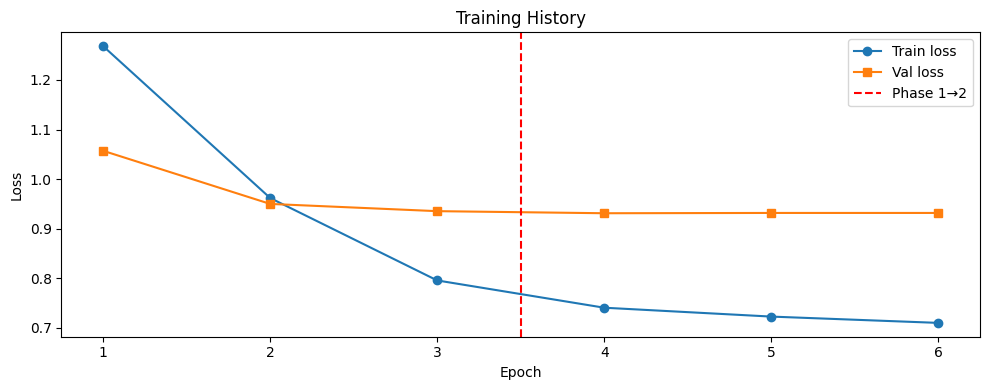

In [15]:
import matplotlib.pyplot as plt

# ─── Reconstruct history from your logs ──────────────────────────────────────
history = {
    'train_loss': [1.2682, 0.9620, 0.7958, 0.7408, 0.7229, 0.7102],
    'val_loss':   [1.0572, 0.9501, 0.9355, 0.9313, 0.9319, 0.9319]
}

# ─── Plot training history ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
epochs = list(range(1, len(history['train_loss']) + 1))

plt.plot(epochs, history['train_loss'], label='Train loss', marker='o')
plt.plot(epochs, history['val_loss'],   label='Val loss',   marker='s')

# Assuming CFG.PHASE1_EPOCHS was 3
plt.axvline(x=3.5, color='red', ls='--', label='Phase 1→2') 

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.tight_layout()

# Save and show
# Save to the current working directory instead of CFG.OUTPUT_DIR
plt.savefig('training_history.png', dpi=120)
plt.show()

In [15]:
!ls -lh /kaggle/working/checkpoints/

total 1.6G
-rw-r--r-- 1 root root 807M Apr 23 01:00 phase1_best.pt
-rw-r--r-- 1 root root 807M Apr 23 02:40 phase2_best.pt


In [16]:
import shutil
from IPython.display import FileLink

# 1. Zip the entire checkpoints folder
shutil.make_archive('my_saved_models', 'zip', '/kaggle/working/checkpoints')

# 2. Create a download link for the zip file
display(FileLink('my_saved_models.zip'))

/kaggle/working/my_saved_models.zip

In [19]:
from bert_score import score as bert_score
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch

# 1. Rebuild the empty model
model = MedicalCaptionModel(vit_name=CFG.VIT_MODEL, gpt_name=CFG.GPT_MODEL, freeze_encoder=False)
model.to(DEVICE)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

# 2. Load your saved weights! 
# ---> CHANGE THE PATH IN THE QUOTES BELOW TO MATCH WHERE YOUR FILE IS! <---
WEIGHTS_PATH = '/kaggle/input/datasets/madhabpadhi/my-med-weights/phase2_best.pt' 

m = model.module if hasattr(model, 'module') else model
m.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()

# 3. Generate captions
all_preds, all_refs, all_ids = [], [], []

eval_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0)
core_model = model.module if hasattr(model, 'module') else model

for batch in tqdm(eval_loader, desc='Generating captions'):
    pv      = batch['pixel_values'].to(DEVICE)
    ref_ids = batch['input_ids']   
    img_ids = batch['image_id']

    refs = tokenizer.batch_decode(ref_ids, skip_special_tokens=True)
    preds = core_model.generate_caption(
        pv, tokenizer,
        beam_size=CFG.BEAM_SIZE,
        max_new_tokens=CFG.MAX_NEW_TOKENS
    )

    all_preds.extend(preds)
    all_refs.extend(refs)
    all_ids.extend(img_ids)

print(f'\nGenerated {len(all_preds)} captions')
print('='*60)
print('Sample Output:')
print('='*60)
for i in range(min(3, len(all_preds))):
    print(f'  REF : {all_refs[i][:150]}')
    print(f'  PRED: {all_preds[i][:150]}')
    print('-'*60)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder is now TRAINABLE


KeyboardInterrupt: 

In [12]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
# If you don't have bert_score installed, uncomment the next line:
# !pip install bert-score
from bert_score import score as bert_score

# 1. Load the Model
print("Loading model weights...")
model = MedicalCaptionModel(vit_name=CFG.VIT_MODEL, gpt_name=CFG.GPT_MODEL, freeze_encoder=False)
model.to(DEVICE)

# Wrap in DataParallel if you have multiple GPUs
if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)

# UPDATE THIS PATH if needed!
WEIGHTS_PATH = '/kaggle/working/checkpoints/phase2_best.pt' 
m = model.module if hasattr(model, 'module') else model
m.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()

# 2. Setup DataLoader
eval_loader = DataLoader(
    val_ds,
    batch_size=4, 
    shuffle=False, 
    num_workers=0 # Keeps Kaggle from freezing!
)

all_preds = []
all_refs = []

# 3. Generate Captions
print("Generating predictions on validation set...")
core_model = model.module if hasattr(model, 'module') else model

with torch.no_grad():
    for batch in tqdm(eval_loader, desc='Inferencing'):
        pv = batch['pixel_values'].to(DEVICE)
        ref_ids = batch['input_ids']
        
        # Decode the real captions (Ground Truth)
        refs = tokenizer.batch_decode(ref_ids, skip_special_tokens=True)
        
        # Generate the AI captions
        preds = core_model.generate_caption(
            pv, tokenizer,
            beam_size=CFG.BEAM_SIZE,
            max_new_tokens=CFG.MAX_NEW_TOKENS
        )
        
        all_preds.extend(preds)
        all_refs.extend(refs)

# 4. Calculate BERTScore
print("\nCalculating BERTScore (this might take a minute)...")
# We use roberta-large as the baseline evaluator for English text
P, R, F1 = bert_score(all_preds, all_refs, lang="en", verbose=True)

# 5. Print Final Results
print('\n' + '='*60)
print('FINAL EVALUATION METRICS')
print('='*60)
print(f"Precision (P) : {P.mean().item():.4f}  <- How much of the generated text was relevant?")
print(f"Recall (R)    : {R.mean().item():.4f}  <- How much of the true text did it successfully capture?")
print(f"F1-Score (F1) : {F1.mean().item():.4f}  <- The overall balance of both (YOUR MAIN SCORE!)")

print('\n' + '='*60)
print('SAMPLE PREDICTIONS')
print('='*60)
for i in range(min(5, len(all_preds))):
    print(f"TRUE : {all_refs[i]}")
    print(f"PRED : {all_preds[i]}")
    print('-'*60)

Loading model weights...


NameError: name 'CFG' is not defined

In [13]:
from pathlib import Path

# ════════════════════════════════════════════
#   EDIT THESE 3 LINES — everything else runs
# ════════════════════════════════════════════
IMAGES_DIR  = Path('/kaggle/input/datasets/madhabpadhi/medical1-0/dev_caption_synth/images')          # folder with ALL test images
CHECKPOINT  = Path('/kaggle/input/datasets/madhabpadhi/my-med-weights/phase2_best.pt')     # your saved weights
OUTPUT_FILE = Path('/kaggle/working/run.txt')                      # submission output
# ════════════════════════════════════════════

# Model settings — must match what you trained
VIT_MODEL      = 'google/vit-base-patch16-224'
GPT_MODEL      = 'gpt2'
BATCH_SIZE     = 8
BEAM_SIZE      = 4
MAX_NEW_TOKENS = 100

In [14]:
import os, re, zipfile, unicodedata
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from transformers import ViTModel, GPT2LMHeadModel, GPT2Tokenizer
from PIL import Image
from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | GPUs: {torch.cuda.device_count()}')

Device: cuda | GPUs: 2


In [15]:
# ── Model (must match your training architecture) ─────────────────────────────
class MedicalCaptionModel(nn.Module):
    def __init__(self, vit_name, gpt_name):
        super().__init__()
        self.encoder = ViTModel.from_pretrained(vit_name)
        enc_dim = self.encoder.config.hidden_size
        self.decoder = GPT2LMHeadModel.from_pretrained(gpt_name)
        dec_dim = self.decoder.config.n_embd
        self.proj = nn.Sequential(
            nn.Linear(enc_dim, dec_dim), nn.GELU(), nn.LayerNorm(dec_dim)
        )
        self.decoder.config.pad_token_id = self.decoder.config.eos_token_id

    @torch.no_grad()
    def generate(self, pixel_values, tokenizer, beam_size, max_new_tokens):
        B = pixel_values.size(0)
        vis = self.proj(self.encoder(pixel_values=pixel_values).last_hidden_state)
        bos = torch.full((B, 1), tokenizer.bos_token_id, dtype=torch.long, device=pixel_values.device)
        inputs_embeds = torch.cat([vis, self.decoder.transformer.wte(bos)], dim=1)
        out = self.decoder.generate(
            inputs_embeds=inputs_embeds,
            max_new_tokens=max_new_tokens,
            num_beams=beam_size,
            early_stopping=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            no_repeat_ngram_size=3,
        )
        return tokenizer.batch_decode(out, skip_special_tokens=True)

# ── Load tokenizer + model + weights ─────────────────────────────────────────
tokenizer = GPT2Tokenizer.from_pretrained(GPT_MODEL)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.bos_token_id = tokenizer.eos_token_id

model = MedicalCaptionModel(VIT_MODEL, GPT_MODEL)

state = torch.load(CHECKPOINT, map_location='cpu')
# Strip 'module.' prefix if saved with DataParallel
if any(k.startswith('module.') for k in state):
    state = {k.replace('module.', ''): v for k, v in state.items()}
model.load_state_dict(state)
model.eval().to(DEVICE)

print(f'✅ Model loaded — {sum(p.numel() for p in model.parameters())/1e6:.1f}M params')

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded — 211.4M params


In [16]:
# ── Collect ALL images from IMAGES_DIR ───────────────────────────────────────
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}

all_images = sorted([
    p for p in IMAGES_DIR.rglob('*') if p.suffix.lower() in IMG_EXTS
])
print(f'Found {len(all_images):,} images in {IMAGES_DIR}')

# ── Dataset ───────────────────────────────────────────────────────────────────
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

class ImageDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        try:
            img = Image.open(p).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), 128)
        return transform(img), p.stem   # stem = filename without extension

loader = DataLoader(ImageDataset(all_images), batch_size=BATCH_SIZE,
                    shuffle=False, num_workers=2, pin_memory=True)

Found 116,461 images in /kaggle/input/datasets/madhabpadhi/medical1-0/dev_caption_synth/images


In [5]:
import pandas as pd
import unicodedata, re, zipfile
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

# ── 1. Clean Function ─────────────────────────────────────────────────────────
def clean(text):
    text = unicodedata.normalize('NFKC', text or 'medical image')
    text = re.sub(r'[\r\n\t|]+', ' ', text)
    text = re.sub(r' {2,}', ' ', text).strip()
    return text or 'medical image'

PHASE_DIR = Path('/kaggle/working/phases')
PHASE_DIR.mkdir(exist_ok=True)

# ── 2. Split List of Images into 10 Chunks (INSTANT) ──────────────────────────
total_images = len(all_images)
chunk_size   = total_images // 10

print(f'Total images : {total_images}')
print(f'Images/phase : {chunk_size}')
print('─' * 50)

# ── 3. Run Phase 1 ────────────────────────────────────────────────────────────
phase = 1
phase_csv = PHASE_DIR / f'phase_{phase:02d}.csv'
zip_path = PHASE_DIR / f'phase_{phase:02d}.zip'

start_idx = (phase - 1) * chunk_size
end_idx   = phase * chunk_size
phase_images = all_images[start_idx:end_idx]

print(f'\nPhase {phase:02d}/10 — images {start_idx}–{end_idx-1} ({len(phase_images)} images)')

# Create a mini DataLoader JUST for this phase
phase_loader = DataLoader(ImageDataset(phase_images), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

phase_results = []
for batch_idx, (pixels, img_ids) in enumerate(tqdm(phase_loader, desc=f'Phase {phase:02d}')):
    pixels = pixels.to(DEVICE)
    try:
        captions = model.generate(pixels, tokenizer, BEAM_SIZE, MAX_NEW_TOKENS)
    except Exception as e:
        print(f'  ⚠️ batch {batch_idx} error: {e}')
        captions = ['medical image'] * len(img_ids)

    for iid, cap in zip(img_ids, captions):
        phase_results.append({'image_id': iid, 'caption': clean(cap)})

df_phase = pd.DataFrame(phase_results)
df_phase.to_csv(phase_csv, index=False)

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(phase_csv, arcname=phase_csv.name)

print(f'  💾 Saved & Zipped → {zip_path.name}  ({len(df_phase):,} captions)')

Total images : 116461
Images/phase : 11646
──────────────────────────────────────────────────

Phase 01/10 — images 0–11645 (11646 images)


Phase 01:   0%|          | 0/1456 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  💾 Saved & Zipped → phase_01.zip  (11,646 captions)


In [2]:
import os, re, zipfile, unicodedata
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from transformers import ViTModel, GPT2LMHeadModel, GPT2Tokenizer
from PIL import Image
from tqdm.auto import tqdm
from pathlib import Path

# ── Paths & Config ────────────────────────────────────────────────────────────
IMAGES_DIR  = Path('/kaggle/input/datasets/madhabpadhi/medical1-0/dev_caption_synth/images')
CHECKPOINT  = Path('/kaggle/input/datasets/madhabpadhi/my-med-weights/phase2_best.pt')
VIT_MODEL   = 'google/vit-base-patch16-224'
GPT_MODEL   = 'gpt2'
BATCH_SIZE  = 8
BEAM_SIZE   = 4
MAX_NEW_TOKENS = 100

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Model Definition ──────────────────────────────────────────────────────────
class MedicalCaptionModel(nn.Module):
    def __init__(self, vit_name, gpt_name):
        super().__init__()
        self.encoder = ViTModel.from_pretrained(vit_name)
        enc_dim = self.encoder.config.hidden_size
        self.decoder = GPT2LMHeadModel.from_pretrained(gpt_name)
        dec_dim = self.decoder.config.n_embd
        self.proj = nn.Sequential(
            nn.Linear(enc_dim, dec_dim), nn.GELU(), nn.LayerNorm(dec_dim)
        )
        self.decoder.config.pad_token_id = self.decoder.config.eos_token_id

    @torch.no_grad()
    def generate(self, pixel_values, tokenizer, beam_size, max_new_tokens):
        B = pixel_values.size(0)
        vis = self.proj(self.encoder(pixel_values=pixel_values).last_hidden_state)
        bos = torch.full((B, 1), tokenizer.bos_token_id, dtype=torch.long, device=pixel_values.device)
        inputs_embeds = torch.cat([vis, self.decoder.transformer.wte(bos)], dim=1)
        out = self.decoder.generate(
            inputs_embeds=inputs_embeds, max_new_tokens=max_new_tokens,
            num_beams=beam_size, early_stopping=True,
            eos_token_id=tokenizer.eos_token_id, pad_token_id=tokenizer.pad_token_id,
            no_repeat_ngram_size=3,
        )
        return tokenizer.batch_decode(out, skip_special_tokens=True)

# ── Load Model ────────────────────────────────────────────────────────────────
tokenizer = GPT2Tokenizer.from_pretrained(GPT_MODEL)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.bos_token_id = tokenizer.eos_token_id

model = MedicalCaptionModel(VIT_MODEL, GPT_MODEL)
state = torch.load(CHECKPOINT, map_location='cpu')
if any(k.startswith('module.') for k in state):
    state = {k.replace('module.', ''): v for k, v in state.items()}
model.load_state_dict(state)
model.eval().to(DEVICE)

# ── Image Dataset ─────────────────────────────────────────────────────────────
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}
all_images = sorted([p for p in IMAGES_DIR.rglob('*') if p.suffix.lower() in IMG_EXTS])

transform = T.Compose([
    T.Resize((224, 224)), T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

class ImageDataset(Dataset):
    def __init__(self, paths): self.paths = paths
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        try: img = Image.open(p).convert('RGB')
        except: img = Image.new('RGB', (224, 224), 128)
        return transform(img), p.stem

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [3]:
import pandas as pd
import unicodedata, re, zipfile

def clean(text):
    text = unicodedata.normalize('NFKC', text or 'medical image')
    text = re.sub(r'[\r\n\t|]+', ' ', text)
    text = re.sub(r' {2,}', ' ', text).strip()
    return text or 'medical image'

PHASE_DIR = Path('/kaggle/working/phases')
PHASE_DIR.mkdir(exist_ok=True)

total_images = len(all_images)
chunk_size   = total_images // 10

print("✅ Setup complete! You can now run Cell 2.")

✅ Setup complete! You can now run Cell 2.


In [4]:
phase = 2
phase_csv = PHASE_DIR / f'phase_{phase:02d}.csv'
zip_path = PHASE_DIR / f'phase_{phase:02d}.zip'

start_idx = (phase - 1) * chunk_size
end_idx   = phase * chunk_size
phase_images = all_images[start_idx:end_idx]

print(f'\nPhase {phase:02d}/10 — images {start_idx}–{end_idx-1} ({len(phase_images)} images)')

phase_loader = DataLoader(ImageDataset(phase_images), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

phase_results = []
for batch_idx, (pixels, img_ids) in enumerate(tqdm(phase_loader, desc=f'Phase {phase:02d}')):
    pixels = pixels.to(DEVICE)
    try:
        captions = model.generate(pixels, tokenizer, BEAM_SIZE, MAX_NEW_TOKENS)
    except Exception as e:
        captions = ['medical image'] * len(img_ids)
    for iid, cap in zip(img_ids, captions):
        phase_results.append({'image_id': iid, 'caption': clean(cap)})

df_phase = pd.DataFrame(phase_results)
df_phase.to_csv(phase_csv, index=False)
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(phase_csv, arcname=phase_csv.name)
print(f'  💾 Saved & Zipped → {zip_path.name}')


Phase 02/10 — images 11646–23291 (11646 images)


Phase 02:   0%|          | 0/1456 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


KeyboardInterrupt: 

In [5]:
import os, re, zipfile, unicodedata, csv
import torch
import torch.nn as nn
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from transformers import ViTModel, GPT2LMHeadModel, GPT2Tokenizer
from PIL import Image
from tqdm.auto import tqdm

# ════════════════════════════════════════════
#  1. SETUP & PATHS (EDIT TEST_IMAGES_DIR)
# ════════════════════════════════════════════
# 👉 CHANGE THIS to your actual Kaggle test images folder!
TEST_IMAGES_DIR = Path('/kaggle/input/datasets/madhabpadhi/test-image/test_synth') 

CHECKPOINT      = Path('/kaggle/input/datasets/madhabpadhi/my-med-weights/phase2_best.pt')
VIT_MODEL       = 'google/vit-base-patch16-224'
GPT_MODEL       = 'gpt2'
BATCH_SIZE      = 8
BEAM_SIZE       = 4
MAX_NEW_TOKENS  = 100

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | GPUs: {torch.cuda.device_count()}')

# ════════════════════════════════════════════
#  2. MODEL DEFINITION & LOADING
# ════════════════════════════════════════════
class MedicalCaptionModel(nn.Module):
    def __init__(self, vit_name, gpt_name):
        super().__init__()
        self.encoder = ViTModel.from_pretrained(vit_name)
        enc_dim = self.encoder.config.hidden_size
        self.decoder = GPT2LMHeadModel.from_pretrained(gpt_name)
        dec_dim = self.decoder.config.n_embd
        self.proj = nn.Sequential(
            nn.Linear(enc_dim, dec_dim), nn.GELU(), nn.LayerNorm(dec_dim)
        )
        self.decoder.config.pad_token_id = self.decoder.config.eos_token_id

    @torch.no_grad()
    def generate(self, pixel_values, tokenizer, beam_size, max_new_tokens):
        B = pixel_values.size(0)
        vis = self.proj(self.encoder(pixel_values=pixel_values).last_hidden_state)
        bos = torch.full((B, 1), tokenizer.bos_token_id, dtype=torch.long, device=pixel_values.device)
        inputs_embeds = torch.cat([vis, self.decoder.transformer.wte(bos)], dim=1)
        out = self.decoder.generate(
            inputs_embeds=inputs_embeds, max_new_tokens=max_new_tokens,
            num_beams=beam_size, early_stopping=True,
            eos_token_id=tokenizer.eos_token_id, pad_token_id=tokenizer.pad_token_id,
            no_repeat_ngram_size=3,
        )
        return tokenizer.batch_decode(out, skip_special_tokens=True)

tokenizer = GPT2Tokenizer.from_pretrained(GPT_MODEL)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.bos_token_id = tokenizer.eos_token_id

model = MedicalCaptionModel(VIT_MODEL, GPT_MODEL)
state = torch.load(CHECKPOINT, map_location='cpu')
if any(k.startswith('module.') for k in state):
    state = {k.replace('module.', ''): v for k, v in state.items()}
model.load_state_dict(state)
model.eval().to(DEVICE)
print('✅ Model loaded successfully!')

# ════════════════════════════════════════════
#  3. DATA PREPARATION
# ════════════════════════════════════════════
def clean(text):
    text = unicodedata.normalize('NFKC', text or 'medical image')
    text = re.sub(r'[\r\n\t|]+', ' ', text)
    text = re.sub(r' {2,}', ' ', text).strip()
    return text or 'medical image'

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}
all_images = sorted([p for p in TEST_IMAGES_DIR.rglob('*') if p.suffix.lower() in IMG_EXTS])
print(f'Found {len(all_images):,} test images.')

transform = T.Compose([
    T.Resize((224, 224)), T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

class ImageDataset(Dataset):
    def __init__(self, paths): self.paths = paths
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        try: img = Image.open(p).convert('RGB')
        except: img = Image.new('RGB', (224, 224), 128)
        return transform(img), p.stem

loader = DataLoader(ImageDataset(all_images), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ════════════════════════════════════════════
#  4. GENERATE CAPTIONS (ONE CONTINUOUS LOOP)
# ════════════════════════════════════════════
print('🚀 Starting prediction on test set...')
results = []
for batch_idx, (pixels, img_ids) in enumerate(tqdm(loader, desc='Generating')):
    pixels = pixels.to(DEVICE)
    try:
        captions = model.generate(pixels, tokenizer, BEAM_SIZE, MAX_NEW_TOKENS)
    except Exception as e:
        print(f'  ⚠️ Error on batch {batch_idx}: {e}')
        captions = ['medical image'] * len(img_ids)
    
    for iid, cap in zip(img_ids, captions):
        results.append({'ID': iid, 'Caption': clean(cap)})

# ════════════════════════════════════════════
#  5. FORMATTING STRICTLY & ZIPPING
# ════════════════════════════════════════════
print('⚙️ Formatting submission to competition rules...')
df = pd.DataFrame(results)

# Remove duplicates just in case
df = df.drop_duplicates(subset='ID', keep='first')

# Write to CSV with strict double quotes
OUTPUT_FILE = Path('/kaggle/working/submission.csv')
df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8', quoting=csv.QUOTE_NONNUMERIC)

# STRICT FIX: Read the file back and strip the trailing empty newline at the bottom
with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
    text = f.read()
with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
    f.write(text.rstrip()) 

# Create the perfectly clean zip
final_zip_path = Path('/kaggle/working/submission_final.zip')
with zipfile.ZipFile(final_zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(OUTPUT_FILE, arcname='submission.csv')

print(f'\n🎉 DONE! {final_zip_path.name} is ready for upload with {len(df)} predictions.')

Device: cuda | GPUs: 2


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully!
Found 15,262 test images.
🚀 Starting prediction on test set...


Generating:   0%|          | 0/1908 [00:00<?, ?it/s]

⚙️ Formatting submission to competition rules...

🎉 DONE! submission_final.zip is ready for upload with 15262 predictions.


In [6]:
from IPython.display import FileLink
FileLink('submission_final.zip')

/kaggle/working/submission_final.zip